# Notes:

This analysis only consider protein detected in LiPMS on control sample and RNA sequencing experiments

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# ----------------------------
# Nature-like rcParams (apply once)
# ----------------------------
BASE_FONTSIZE = 8
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": BASE_FONTSIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.labelsize": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.linewidth": 0.8,
    "axes.spines.right": False,
    "axes.spines.top": False,

    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "legend.fontsize": BASE_FONTSIZE,
    "legend.frameon": False,

    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


In [3]:
# Plot function
# ----------------------------
# Panel A: Volcano (Nature style)
# ----------------------------
def plot_panel_a_volcano(df, p_thresh=0.01, xlim=(-13, 13.5), ylim=(0, 7.5)):
    # df must have columns: log2FC, Pvalue, SC (1 for ASC, else NASC)
    d = df.copy()
    d["-log10_Pvalue"] = -np.log10(d["Pvalue"].astype(float))

    df_asc = d[d["SC"] == 1]
    df_nasc = d[d["SC"] != 1]

    fig, ax = plt.subplots(figsize=(3.50, 2.80))  # single-column panel

    # Points: small, high density friendly
    ax.scatter(df_nasc["log2FC"], df_nasc["-log10_Pvalue"],
               s=6, c="black", alpha=0.65, linewidths=0, label="NASC", rasterized=True)
    ax.scatter(df_asc["log2FC"], df_asc["-log10_Pvalue"],
               s=6, c="blue", alpha=0.65, linewidths=0, label="ASC", rasterized=True)

    # Threshold lines: thin, dashed
    ax.axvline(0, linestyle="--", linewidth=0.8, color="red")
    ax.axhline(-np.log10(p_thresh), linestyle="--", linewidth=0.8, color="red")

    ax.set_xlabel(r"$\log_2(\mathrm{Normalized\ FC})$")
    ax.set_ylabel(r"$-\log_{10}(P)$")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

#     ax.legend(loc="upper left", handletextpad=0.3, borderaxespad=0.2, labelspacing=0.2)

#     # panel label
#     ax.text(-0.18, 1.02, "a", transform=ax.transAxes,
#             ha="left", va="bottom", fontsize=9, fontweight="bold")

    plt.show()
    return fig, ax


# ----------------------------
# Panel B: 2x2 table (Nature style)
# ----------------------------
def plot_panel_b_table(
    counts=((165, 288),
            (594, 1514)),
    row_labels=("Yes", "No"),
    col_labels=("Yes", "No"),
    title_top="Age-associated abundance increase",
    title_left="Age-associated\nstructural change",
    figsize=(3.50, 2.80),
):
    fig, ax = plt.subplots(figsize=figsize)  # single-column panel
    ax.axis("off")

    # Table geometry
    bbox = [0.34, 0.38, 0.56, 0.30]  # [left, bottom, width, height]

    table = ax.table(
        cellText=[[f"{x:,}" for x in row] for row in counts],
        cellLoc="center",
        loc="center",
        bbox=bbox,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(BASE_FONTSIZE)

    for cell in table.get_celld().values():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.set_facecolor("white")
        cell.PAD = 0.14

    # Column labels (above, no boxes)
    for i, lab in enumerate(col_labels):
        x = bbox[0] + (i + 0.5) * bbox[2] / 2
        y = bbox[1] + bbox[3] + 0.03
        ax.text(x, y, lab, ha="center", va="bottom", fontsize=BASE_FONTSIZE)

    # Column title
    ax.text(
        bbox[0] + bbox[2] / 2,
        bbox[1] + bbox[3] + 0.12,
        title_top,
        ha="center",
        va="bottom",
        fontsize=BASE_FONTSIZE,
    )

    # Row labels (left of table)
    for i, lab in enumerate(row_labels):
        y = bbox[1] + bbox[3] - (i + 0.5) * bbox[3] / 2
        x = bbox[0] - 0.03
        ax.text(x, y, lab, ha="right", va="center", fontsize=BASE_FONTSIZE)

    # Left title (vertical)
    ax.text(
        bbox[0] - 0.16,
        bbox[1] + bbox[3] / 2,
        title_left,
        ha="center",
        va="center",
        rotation=90,
        fontsize=BASE_FONTSIZE,
    )



#     # panel label
#     ax.text(-0.18, 1.02, "b", transform=ax.transAxes,
#             ha="left", va="bottom", fontsize=9, fontweight="bold")

    plt.show()
    return fig, ax



In [4]:
df = pd.read_pickle('../data/protein_abundances/Protein_Abundance_control_sample.pkl')
SGD2Uni = pd.read_pickle('../data/protein_abundances/SGD2Uniprot.pkl')
# mRNA fold-change
normalization_factor = pd.read_pickle('../data/protein_abundances/Normalization_factor.pkl')
# LiP-data, peptide exhibit significant fold-change
df_lip = pd.read_pickle('../data/protein_abundances/Normalized_LiP_peptides_significant.pkl')
df_AF = pd.read_pickle('../data/protein_abundances/AF_Yeast_entanglement.pkl') #to get protein length
df_AF = df_AF.drop(columns=['fragment', 'uniprot_fragment', 'plddt', 'whGLN', 'entanglement_AF'])

In [5]:
# first 3 numbers are Old. last 3 numbers are Young
# Processing data
# 1. Drop column "Description"
df = df.drop(columns=["Description"])

# 2. Rename replicate columns
df = df.rename(columns={
    "Replicate 1": "O1",
    "Replicate 2": "O2",
    "Replicate 3": "O3",
    "Replicate 1.1": "Y1",
    "Replicate 2.1": "Y2",
    "Replicate 3.1": "Y3"
})
# 3. Drop rows where all replicate values are NaN
replicate_cols = ["O1", "O2", "O3", "Y1", "Y2", "Y3"]
df = df.dropna(subset=replicate_cols, how="any") #'any' or 'all' give similar results

In [6]:
df = df.merge(SGD2Uni[["SGDID", "Uniprot"]], on="SGDID", how="left")
# reorder columns
df = df[[
    "Accession",
    "SGDID",
    "Uniprot",
    "O1", "O2", "O3",
    "Y1", "Y2", "Y3"
]]

In [7]:
# ---- Compute Fold-change and p-value per row ----
def compute_stats(row):
    O = np.array([row["O1"], row["O2"], row["O3"]], dtype=float)
    Y = np.array([row["Y1"], row["Y2"], row["Y3"]], dtype=float)

    # handle case where all Y are 0
    if np.all(Y == 0):
        fc = 1
        p = 1
    else:
        fc = np.mean(O) / np.mean(Y)
        p = sp.stats.ttest_ind(O, Y, equal_var=False).pvalue
    return pd.Series([fc, p])

In [8]:
# compute FC and p-value
df[['FC', 'Pvalue']] = df.apply(compute_stats, axis=1)

df = df.merge(normalization_factor, on='Accession', how='inner')
df['FC_norm'] = df['FC']/df['NormFactor']
# df[df['NormFactor']!=1]
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813
2568,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431
2569,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801
2570,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603


In [9]:
# merge entanglement
df = df.merge(df_AF[["Uniprot", "length_AF"]], on="Uniprot", how="inner")
df['length_z'] = (df['length_AF'] - df['length_AF'].mean())/df['length_AF'].std()
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm,length_AF,length_z
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780,835,0.899190
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004,617,0.307061
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452,433,-0.192718
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616,144,-0.977696
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195,334,-0.461621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813,696,0.521640
2557,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431,288,-0.586565
2558,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801,709,0.556950
2559,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603,279,-0.611011


In [10]:
# extract SC from LiPMS (without plddt info)
df_lip = df_lip.merge(SGD2Uni, on='SGDID', how='left')
SC_proteins = df_lip['Uniprot'].unique().tolist()
df_lip

,peptides,proteotypicity,trypticity,Start AA,End AA,Protein name,Description,Protein abundance change old/young,Normalized peptide abundance ratio old/young,qvalue old/young,SGDID,Uniprot
0,RPTSAYFLYLQDHR,1,FT,44,59,ABF2,"ABF2 SGDID:S000004676, Chr XIII from 411569-41...",1.000000,1249.384890,0.011246,S000004676,Q02486
1,VSAIFSTPLQHIVELESK,1,FT,998,1017,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,16.616413,0.008208,S000005299,Q00955
2,IGSFGPQEDEFFNKVTEYAR,1,FT,1592,1613,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,65.122841,0.031076,S000005299,Q00955
3,AIQVEGQPIILT,1,HT,1745,1758,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,0.188901,0.012240,S000005299,Q00955
4,EGVTVPIVEWK,1,HT,1121,1133,ACC1,"ACC1 SGDID:S000005299, Chr XIV from 661374-654...",2.022110,0.137421,0.028971,S000005299,Q00955
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,NNLGYSKDQVFKF,1,HT,289,303,MCR1,"MCR1 SGDID:S000001633, Chr XI from 166544-1674...",1.000000,0.159863,0.024164,S000001633,P36060
1268,DIANRIGYI,1,HT,133,143,RPL25,"RPL25 SGDID:S000005487, Chr XV from 80348-8036...",0.656078,0.136421,0.010854,S000005487,P04456
1269,AKIAALAGQQ,1,HT,287,298,RPL5,"RPL5 SGDID:S000006052, Chr XVI from 303121-304...",3.385618,0.113018,0.012452,S000006052,P26321
1270,GGNLDMGDFKENDEEDEEEEIEPEVKA,1,HT,189,217,SBA1,"SBA1 SGDID:S000001600, Chr XI from 220324-2209...",0.764479,9.440744,0.023145,S000001600,P28707


In [11]:
len(SC_proteins)

468

In [12]:
# add SC back to df
df['SC']= df['Uniprot'].isin(SC_proteins).astype(int)
df

,Accession,SGDID,Uniprot,O1,O2,O3,Y1,Y2,Y3,FC,Pvalue,NormFactor,FC_norm,length_AF,length_z,SC
0,YPL019C,S000005940,Q02725,4.178885e+07,4.204768e+07,4.198175e+07,1.267989e+07,1.271294e+07,1.275959e+07,3.297780,1.242862e-06,1.0,3.297780,835,0.899190,1
1,YNL121C,S000005065,P07213,1.750116e+07,1.663523e+07,1.679759e+07,9.744688e+06,8.954282e+06,9.057904e+06,1.835004,3.008348e-05,1.0,1.835004,617,0.307061,0
2,YNL220W,S000005164,P80210,1.847388e+07,1.838129e+07,1.821648e+07,1.010788e+07,1.011520e+07,9.879726e+06,1.829452,1.708323e-07,1.0,1.829452,433,-0.192718,1
3,YNL302C,S000005246,P07281,2.520388e+08,2.304209e+08,2.246568e+08,5.629927e+08,5.403837e+08,5.387276e+08,0.430616,1.115359e-05,1.0,0.430616,144,-0.977696,0
4,YPL227C,S000006148,P40350,3.546039e+05,4.089249e+05,4.319773e+05,1.903457e+04,7.728805e+04,9.572053e+04,6.225195,5.064652e-04,1.0,6.225195,334,-0.461621,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,YIL108W,S000001370,P40483,8.809438e+05,4.323921e+05,8.406757e+05,6.654727e+05,6.812586e+05,8.141677e+05,0.996813,9.890174e-01,1.0,0.996813,696,0.521640,0
2557,YOR362C,S000005889,P21242,1.057500e+07,1.185353e+07,1.153441e+07,1.128266e+07,1.175196e+07,1.091369e+07,1.000431,9.920350e-01,1.0,1.000431,288,-0.586565,0
2558,YAR014C,S000000069,P27637,1.230791e+06,6.280753e+05,4.607515e+05,8.046273e+05,7.592260e+05,7.632091e+05,0.996801,9.925041e-01,1.0,0.996801,709,0.556950,0
2559,YJL115W,S000003651,P32447,2.170228e+06,1.862165e+06,1.999362e+06,1.981641e+06,2.044287e+06,2.008224e+06,0.999603,9.937342e-01,1.0,0.999603,279,-0.611011,0


In [13]:
df['log2FC'] = np.log2(df['FC_norm'])
df["Abd_up"] = ((df["FC_norm"] > 1) & (df["Pvalue"] < 0.01)).astype(int)

/Users/qvv256789/miniconda3/envs/bioenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Abd_up ~ SC

In [14]:
YY = len(df[(df['SC']==1) & (df['Abd_up']==1)])
YN = len(df[(df['SC']==1) & (df['Abd_up']==0)])
NY = len(df[(df['SC']==0) & (df['Abd_up']==1)])
NN = len(df[(df['SC']==0) & (df['Abd_up']==0)])

table = [[YY, YN],
        [NY, NN]]
print(table)
OR, pval = sp.stats.fisher_exact(table)
# print(OR, pval)
ci_low, ci_upp = sm.stats.Table2x2(table).oddsratio_confint()

print("OR:", OR)
print("95% CI:", (ci_low, ci_upp))

print("p-value:", pval)

print("="*50)
model = smf.logit('Abd_up ~ SC+length_z', data=df)
result = model.fit()
print(result.summary())

params = result.params
conf = result.conf_int(alpha=0.05)
pvals = result.pvalues

for var in params.index:
    est = params[var]
    ci_low, ci_high = conf.loc[var]
    pval = pvals[var]

    print(
        f"{var}: {np.exp(est):.3f}, "
        f"[{np.exp(ci_low):.3f}, {np.exp(ci_high):.3f}], "
        f"p = {pval:.3e}"
    )

[[165, 288], [594, 1514]]
OR: 1.4602623456790123
95% CI: (np.float64(1.1794137711431514), np.float64(1.8079881466375984))
p-value: 0.0006543737472406346
Optimization terminated successfully.
         Current function value: 0.598620
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 Abd_up   No. Observations:                 2561
Model:                          Logit   Df Residuals:                     2558
Method:                           MLE   Df Model:                            2
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.01503
Time:                        15:51:00   Log-Likelihood:                -1533.1
converged:                       True   LL-Null:                       -1556.5
Covariance Type:            nonrobust   LLR p-value:                 6.902e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

In [15]:
# df.to_pickle('protein_abundance_normalized.pkl')

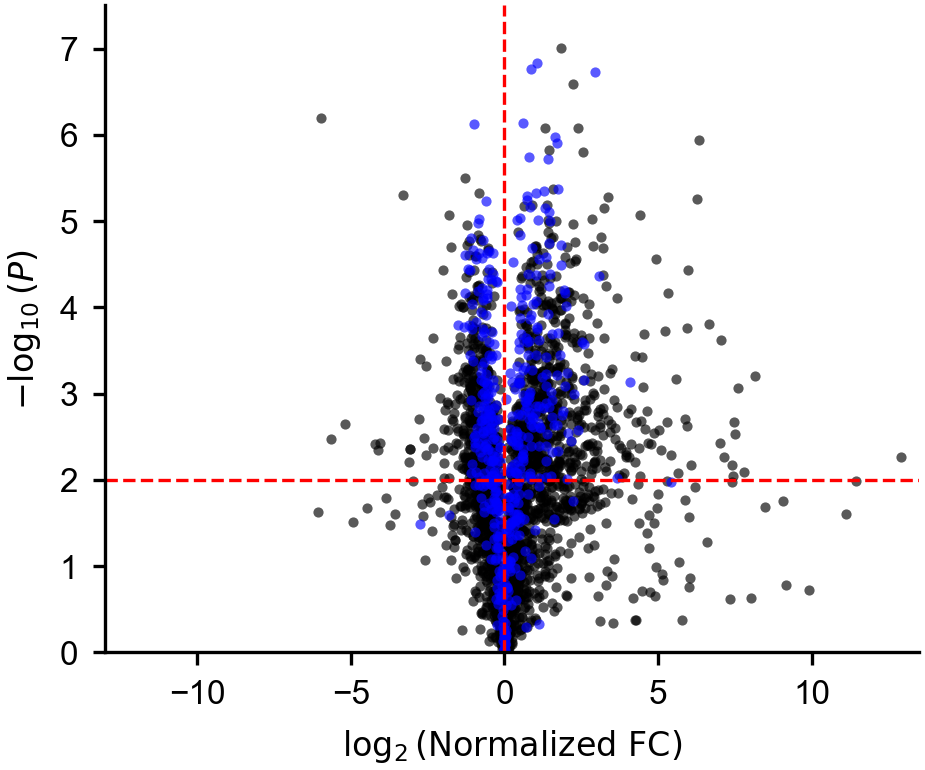

In [16]:
fig_a, ax_a = plot_panel_a_volcano(df)

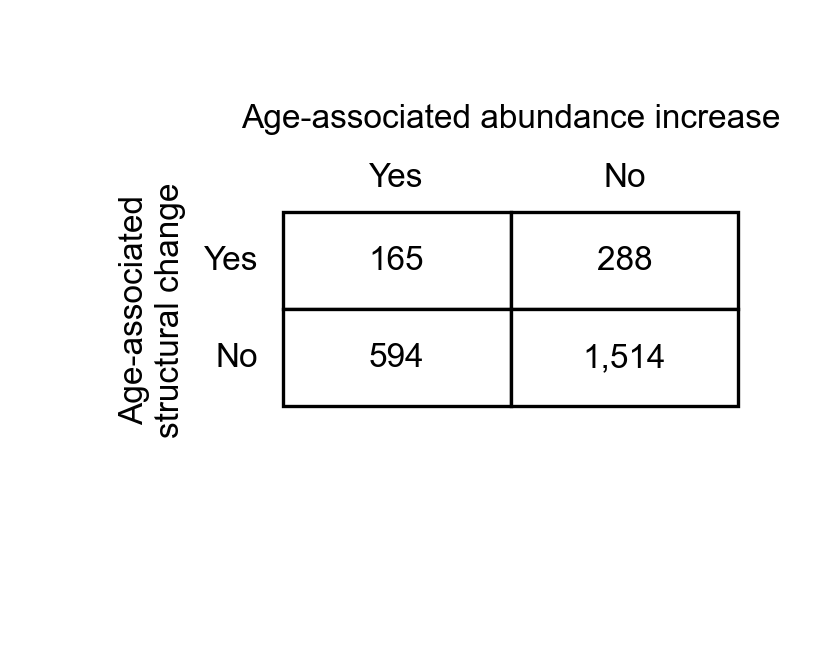

In [17]:
fig_b, ax_b = plot_panel_b_table()